In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
import os

In [3]:
num_p = 8
magnetizzazione_df = pd.read_csv("./results/risultati_%dp.csv" %(num_p))

In [4]:
L_values = np.array(magnetizzazione_df['L'].unique())
beta_values = np.array(magnetizzazione_df['beta'].unique())

In [5]:
gruppi_L = magnetizzazione_df.groupby('L')

m = {}
err = {}

for L in L_values:
    # Salviamo l'intero array usando L come chiave
    m[L] = gruppi_L.get_group(L)['<M>'].values
    err[L] = gruppi_L.get_group(L)['errore su <M>'].values

In [10]:
def magnetizzazione_analitica(J=1.0):
    """
    Calcola la curva teorica della magnetizzazione spontanea per il modello di Ising 2D.
    
    Parametri:
    - J: Costante di accoppiamento (default 1.0)
    
    Ritorna:
    - beta: array numpy da 0 a 1 con passo 0.001
    - m_analitico: array numpy con i valori della magnetizzazione teorica
    """
    # Costruiamo l'array di beta da 0 a 1 a passi di 0.001
    # np.arange(start, stop, step) -> mettiamo 1.001 per includere l'1.0 finale
    beta = np.arange(0.0001, 1.001, 0.001)
    
    # Inizializziamo il vettore analitico con tutti zeri
    m_analitico = np.zeros_like(beta)
    
    # Calcolo del beta critico teorico: beta_c = ln(1 + sqrt(2)) / (2J)
    beta_c = 0.5 * np.log(1 + np.sqrt(2)) / J
    
    # Creiamo una maschera booleana per selezionare solo i beta > beta_c
    # Al di sotto di beta_c (alta temperatura), la magnetizzazione spontanea è 0
    mask = beta > beta_c
    
    # Applichiamo la formula ESATTA solo nella regione ordinata (beta > beta_c)
    # Formula: m = (1 - (sinh(2 * beta * J))^-4)^(1/8)
    m_analitico[mask] = (1.0 - (np.sinh(2 * beta[mask] * J))**(-4))**(1/8)

    
    return beta, m_analitico

betas, m_analitico = magnetizzazione_analitica()

In [ ]:
plt.rcParams.update({
    "text.usetex": True,         # Usa il vero compilatore LaTeX
    "text.latex.preamble": r"\usepackage{txfonts}", # Carica i font di Elsevier
    "font.family": "serif",      
    
    # --- DIMENSIONI ---
    "font.size": 12,             
    "axes.titlesize": 12,        
    "axes.labelsize": 11,        
    "xtick.labelsize": 10,       
    "ytick.labelsize": 10,       
    "legend.fontsize": 10,       
    
    # --- ESPORTAZIONE ---
    "figure.figsize": (3.5, 2.5), 
    "figure.dpi": 300            
})

## 1. Phase Transition and Spontaneous Magnetization

The graph illustrates the behavior of the absolute spontaneous magnetization $\langle |M| \rangle$ as a function of the inverse temperature $\beta$ for the 2D Ising model. 

To accurately characterize the phase transition, the system was simulated across a range of $\beta$ values from **0** to **1**. Specifically, the sampled points are: 
* **0.1, 0.2, 0.3, 0.35, 0.4, 0.42, 0.43, 0.44, 0.45, 0.46, 0.48, 0.5, 0.55, 0.6, 0.7, 0.8**

As shown in the plot, the measurements are significantly denser around the theoretical critical point $\beta_c \approx$ **0.4406**. This fine-grained sampling strategy is crucial to precisely capture the sharp drop in magnetization that characterizes the spontaneous symmetry breaking.


### 1.1 Finite-Size Scaling and Thermodynamic Limit

The plot compares the numerical results obtained for four different lattice sizes ($L = 16, 32, 64, 128$) against the exact analytical solution (represented by the black dashed line).

* **Small lattices ($L = 16, 32$):** These curves exhibit a noticeably smoother transition. Due to their limited spatial extension, the system experiences significant thermal fluctuations even below the critical $\beta$, resulting in a non-zero magnetization tail in the disordered phase.
* **Large lattices ($L = 128$):** The red curve, associated with the largest simulated lattice, is clearly the most consistent with the analytical solution. Increasing the lattice size successfully minimizes the **finite-size effects**, leading to a much sharper phase transition that closely approximates the behavior of an infinite system approaching the true thermodynamic limit ($L \to \infty$).

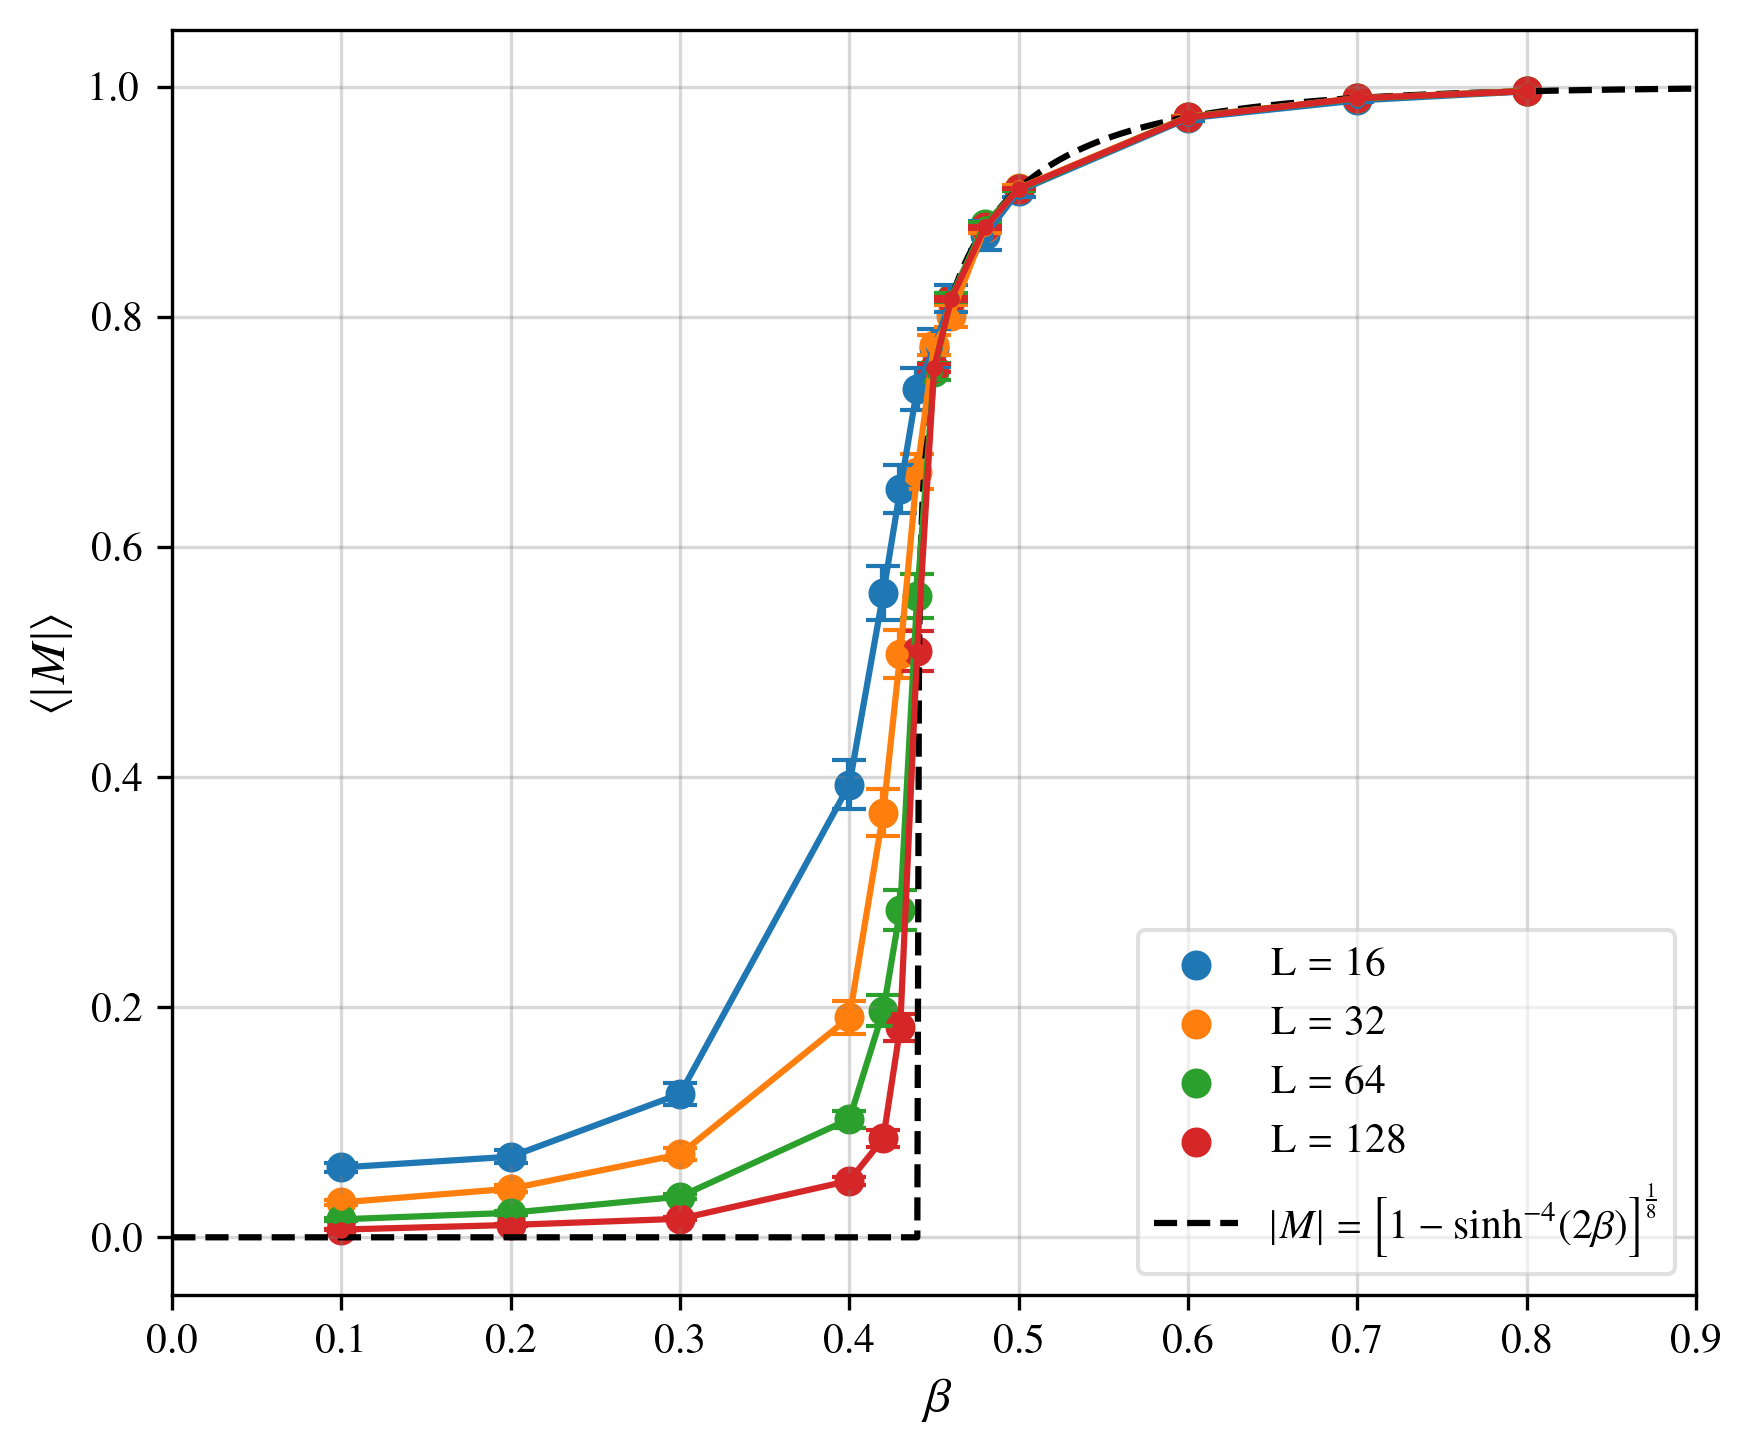

In [12]:
plt.figure(figsize=(6, 5))
for L in L_values:
    plt.scatter(beta_values, m[L], linewidth=1.2, linestyle='-', label='L = %d' %(L))
    plt.errorbar(beta_values, m[L], yerr=err[L], marker='o', linestyle='-', markersize=3, capsize=4)

plt.plot(betas, m_analitico, c='black', linestyle='--', label=r"$|M| = \left[1 - \sinh^{-4}(2\beta)\right]^{\frac{1}{8}}$")
plt.xlabel(r'$\beta$', fontsize=12)
plt.xlim(0, 0.9)
plt.ylabel(r'$\langle |M| \rangle$', fontsize=12)
plt.legend(loc='lower right', fontsize=10, framealpha=0.6)
plt.grid(True, which='both', color='gray', alpha=0.3)
plt.tight_layout()

plt.savefig("./assets/transizione_di_fase.png")
plt.show()

## 2 Microscopic Configurations and Spin Dynamics

The static snapshots and the animated GIFs illustrate the microscopic behavior of the $128 \times 128$ lattice at dynamic equilibrium. By analyzing the system at three key temperatures, we can visually grasp the mechanics of the 2D Ising phase transition.

### 2.1 Static Snapshots Analysis
* **Disordered Phase ($\beta = 0.200$):** At high temperatures, thermal agitation vastly overpowers the ferromagnetic exchange interaction ($J$). The spins are completely randomized, resembling static noise. Because $+1$ and $-1$ spins are equally distributed, the macroscopic average magnetization is practically zero ($\langle m \rangle \approx 0$).
* **Critical Point ($\beta = 0.440$):** Near the critical temperature, the system undergoes a radical structural change. We witness the emergence of large, macroscopic clusters. Huge domains of opposite spins fiercely "compete" with one another. 
* **Ordered Phase ($\beta = 0.800$):** At low temperatures, the exchange interaction dominates, leading to spontaneous symmetry breaking. One spin orientation takes over the entire lattice, pushing the absolute magnetization close to unity ($|m| \approx 1$). However, the alignment is not entirely perfect: since the temperature is not strictly absolute zero ($T > 0$), residual thermal noise continuously flips isolated spins, which appear as tiny dots across the predominantly monochromatic background.

Estrazione fotogramma per beta = 0.2...
Estrazione fotogramma per beta = 0.44...
Estrazione fotogramma per beta = 0.8...

Figura salvata con successo in: ./assets/snapshots_L128.png


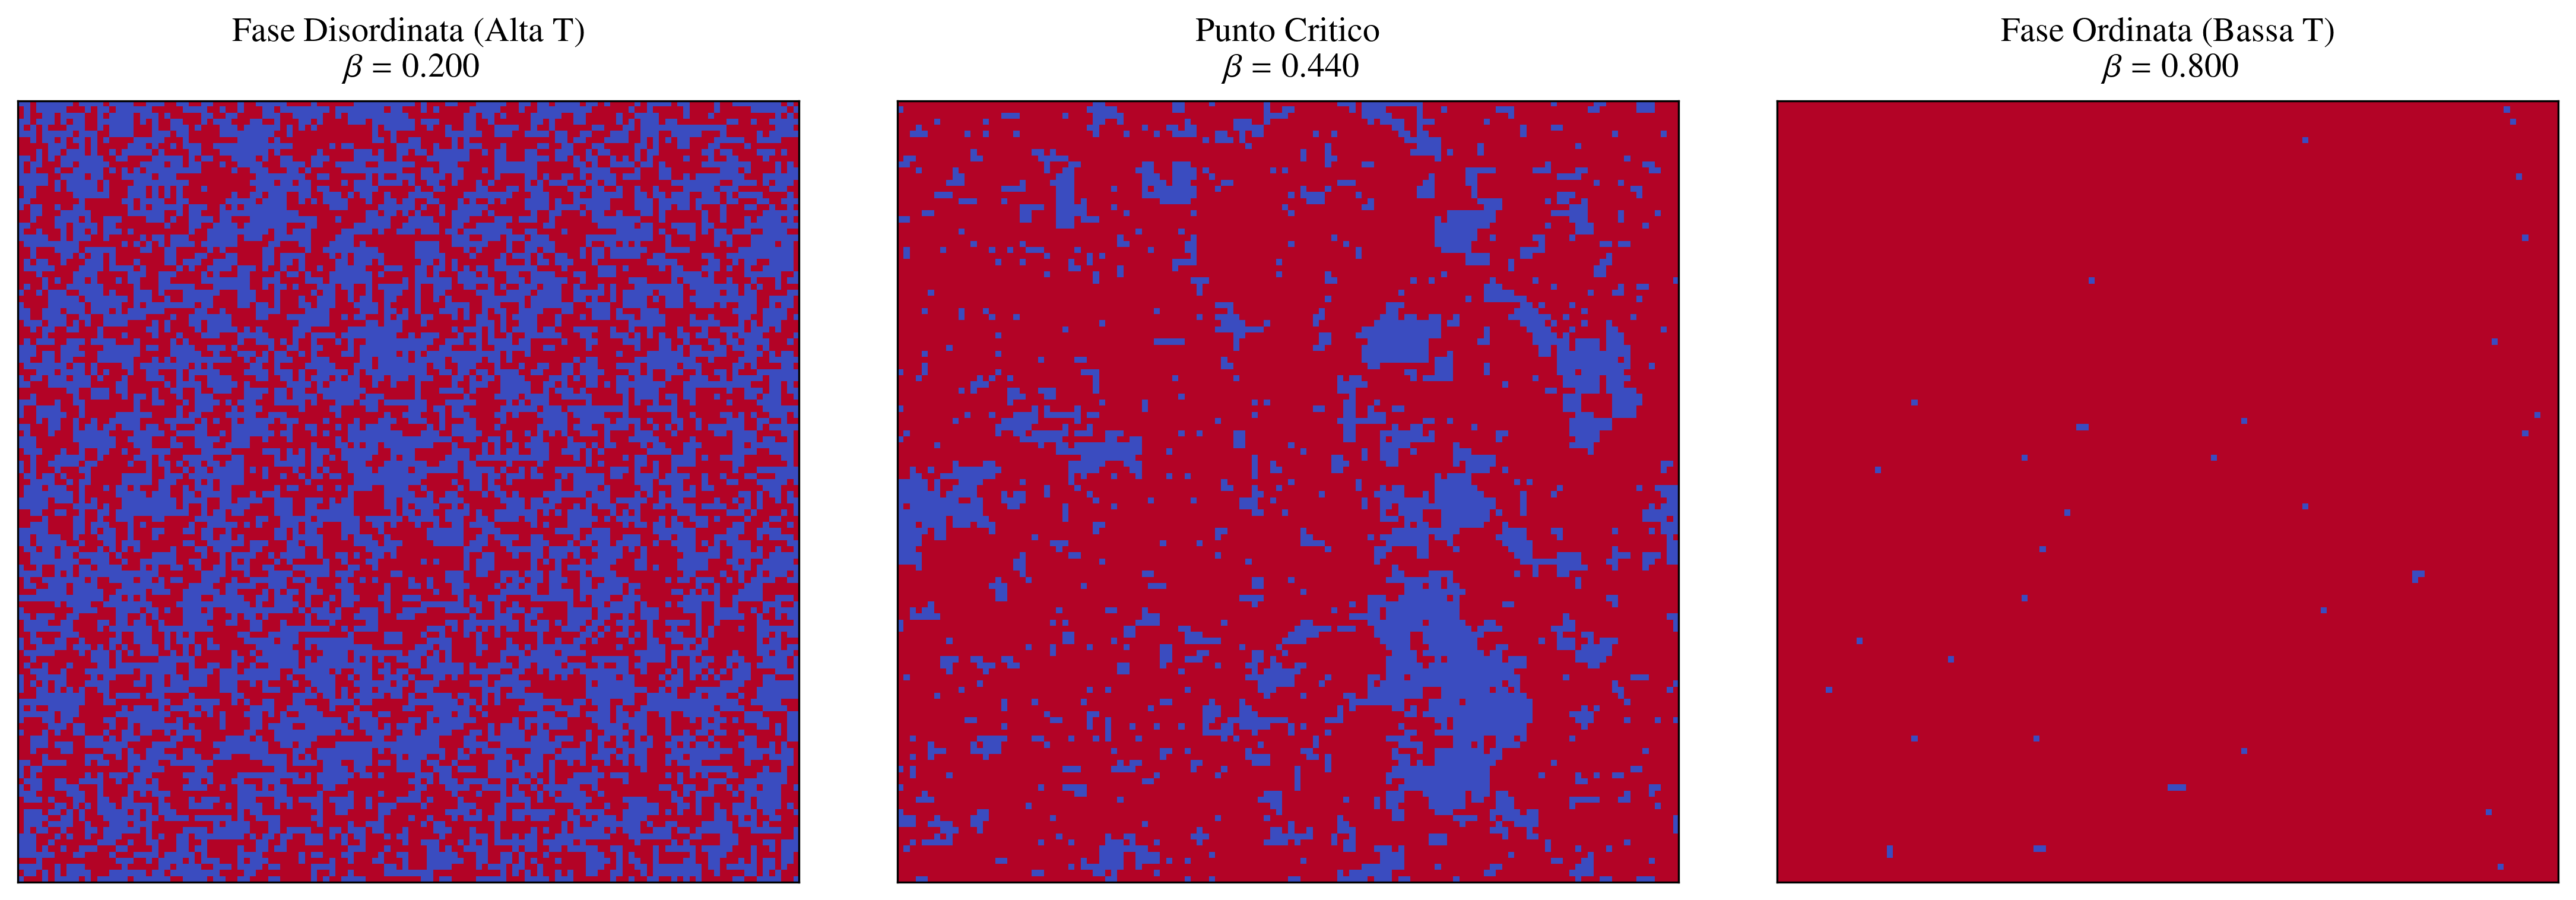

In [ ]:
# Parametri target
L_target = 128
betas_target = [0.200, 0.440, 0.800]
labels = ["Fase Disordinata (Alta T)", "Punto Critico", "Fase Ordinata (Bassa T)"]

# Funzione per estrarre l'ultimo frame dal file
def get_last_frame(L, beta):
    filename = f"./simulations/L_{L}/traiettoria_L_{L}_beta_{beta:.3f}.txt"
    last_matrix = None
    
    if not os.path.exists(filename):
        print(f"ERRORE: File non trovato -> {filename}")
        return None

    with open(filename, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith("L:"):
            # Trovata un'intestazione, saltiamo alla matrice
            i += 1
            matrix = []
            for _ in range(L):
                row = [int(x) for x in lines[i].split()]
                matrix.append(row)
                i += 1
            # Aggiorniamo la variabile: a fine ciclo conterrà l'ultimo frame
            last_matrix = np.array(matrix)
        else:
            i += 1
            
    return last_matrix

# Setup della figura orizzontale: 1 riga, 3 colonne
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cmap = plt.cm.coolwarm

# Popoliamo i tre subplot
for idx, (beta, ax, label) in enumerate(zip(betas_target, axes, labels)):
    print(f"Estrazione fotogramma per beta = {beta}...")
    frame = get_last_frame(L_target, beta)
    
    if frame is not None:
        ax.imshow(frame, cmap=cmap, vmin=-1, vmax=1, interpolation='none')
    
    # Formattazione del subplot
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{label}\n$\\beta$ = {beta:.3f}", fontsize=14, pad=10)

# Ottimizzazione degli spazi e salvataggio
plt.tight_layout()

# Assicuriamoci che la cartella esista
os.makedirs("./assets", exist_ok=True)
output_path = f"./assets/snapshots_L{L_target}.png"

plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

### 2.2 Dynamic Equilibrium (Animated GIFs)
The provided GIFs show the lattice evolution specifically during the **measurement phase**, which occurs strictly after the initial thermalization sweeps. 

Because the system has already reached its thermal dynamic equilibrium for a fixed $\beta$, you will not see a progression from disorder to order. Instead, the animations capture the system continuously fluctuating between energetically equivalent microstates. These visual oscillations represent the concept of statistical thermodynamic fluctuations: the macrostate (e.g., the average magnetization) remains stable, while the underlying microscopic configuration constantly evolves through single-spin Metropolis flips.

Leggendo i dati da ./simulazioni/L_128/traiettoria_L_128_beta_0.800.txt...
Trovati 100 fotogrammi. Generazione della GIF in corso...


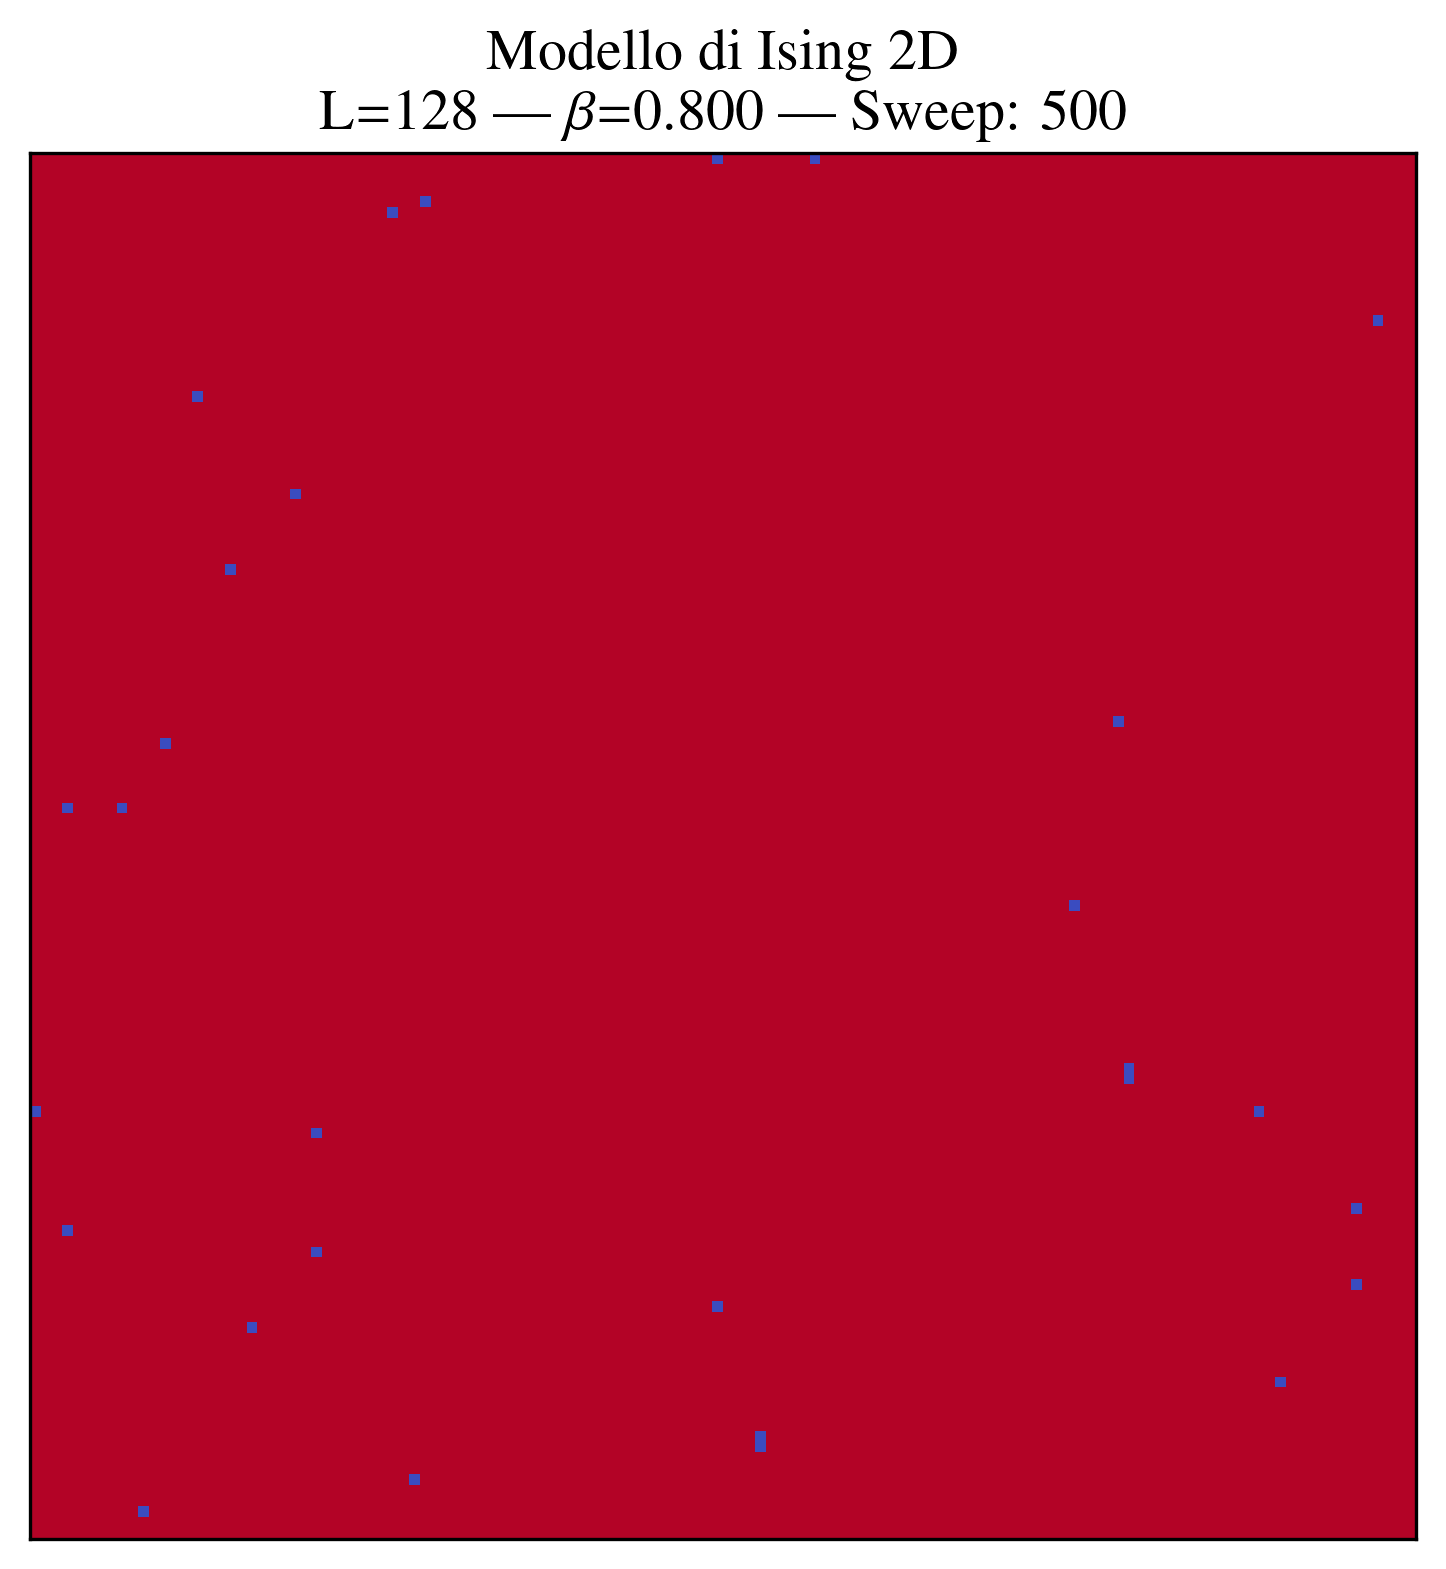

In [ ]:
L_target=128
beta_target = 0.800

filename = ("./simulations/L_%d/traiettoria_L_%d_beta_%.3f.txt" %(L_target, L_target, beta_target))

frames = []
sweeps = []

print(f"Leggendo i dati da {filename}...")

# 3. Leggiamo il file e isoliamo solo i frame che ci interessano
with open(filename, 'r') as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i].strip()
    # Cerchiamo l'intestazione del fotogramma
    if line.startswith("L:"):
        parts = line.split()
        L = int(parts[1])
        beta = float(parts[3])
        sweep = int(parts[5])
        
        i += 1 # Passiamo alla prima riga della matrice
        
        # Leggiamo la matrice L x L
        matrix = []
        for _ in range(L):
            row = [int(x) for x in lines[i].split()]
            matrix.append(row)
            i += 1
            
        # Se il frame corrisponde a L e Beta scelti, lo salviamo
        if L == L_target and abs(beta - beta_target) < 0.001:
            frames.append(np.array(matrix))
            sweeps.append(sweep)
    else:
        i += 1

if not frames:
    print("ERRORE: Nessun frame trovato per i parametri scelti. Controlla che L e Beta siano giusti!")
    exit()

print(f"Trovati {len(frames)} fotogrammi. Generazione della GIF in corso...")

# 4. Creiamo l'animazione
fig, ax = plt.subplots(figsize=(6, 6))

# Usiamo la colormap 'coolwarm' (Blu per gli spin -1, Rosso per gli spin +1)
cmap = plt.cm.coolwarm
matrice_plot = ax.imshow(frames[0], cmap=cmap, vmin=-1, vmax=1, interpolation='none')

# Togliamo i numeri dagli assi per renderlo più "pulito"
ax.set_xticks([])
ax.set_yticks([])
titolo = ax.set_title(f"Modello di Ising 2D\nL={L_target} | $\\beta$={beta_target:.3f} | Sweep: {sweeps[0]}", fontsize=14)

# Funzione che aggiorna il grafico a ogni fotogramma
def update(frame_idx):
    matrice_plot.set_data(frames[frame_idx])
    titolo.set_text(f"Modello di Ising 2D\nL={L_target} | $\\beta$={beta_target:.3f} | Sweep: {sweeps[frame_idx]}")
    return matrice_plot, titolo

# Creiamo l'oggetto animazione (intervallo di 100ms tra i frame)
ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=100, blit=False)

ani.save('./assets/gif/ising_L%d_B%.3f.gif' %(L_target, beta_target), writer='pillow', fps=10)

## 3. Strong Scaling and Speedup Analysis

The provided graphs illustrate the **strong scaling** performance of the parallelized Ising model. The goal of this benchmark is to evaluate how computational efficiency improves as the number of processes (N) increases, keeping the global problem size (L) fixed.

To isolate and accurately evaluate the true algorithmic efficiency, the speedup was calculated considering two specific metrics:
* **Pure computational time** (blue line).
* **Computation + communication time** (green dashed line), which includes the necessary MPI halo exchange overhead required to update the lattice boundaries.

*Note: I/O operations (saving and writing data to disk) were intentionally excluded from these calculations. Disk access acts as a severe, non-scalable bottleneck that would mask the actual parallel performance of the algorithm.*

### 3.1 Deviation from the Ideal Speedup
As seen in the subplots, the measured speedup naturally deviates from the theoretical **Ideal speedup** (black dotted line). This behavior is expected and can be attributed to two main factors:

1. **Amdahl's Law and Serial Portions:** As dictated by Amdahl's Law, ideal linear speedup is impossible to achieve because not all parts of the code can be parallelized. For instance, in this implementation, the data gathering and the calculation of global statistical averages and standard deviations are performed exclusively by the root process (rank 0). This inevitable serial fraction inherently limits the maximum achievable speedup.
2. **Hardware Limitations and Load Balancing:** The specific local machine used for these benchmarks is equipped with only **6 physical cores**. Despite this hardware constraint, the tests were intentionally run up to **N = 8** processes. This design choice was made to strictly maintain domain decompositions based on powers of 2. Using an intermediate number of processes (like N = 6) would have resulted in non-exact geometric divisions of the lattice and remainders. In a synchronous MPI environment, such an uneven load distribution would force all processes to sit idle while waiting for the single slowest, most heavily loaded rank to finish its task, ultimately degrading the overall performance even further.

Caricato correttamente: ./tempi_esecuzione/tempi_speedup_1.csv
Caricato correttamente: ./tempi_esecuzione/tempi_speedup_2.csv
Caricato correttamente: ./tempi_esecuzione/tempi_speedup_4.csv
Caricato correttamente: ./tempi_esecuzione/tempi_speedup_8.csv


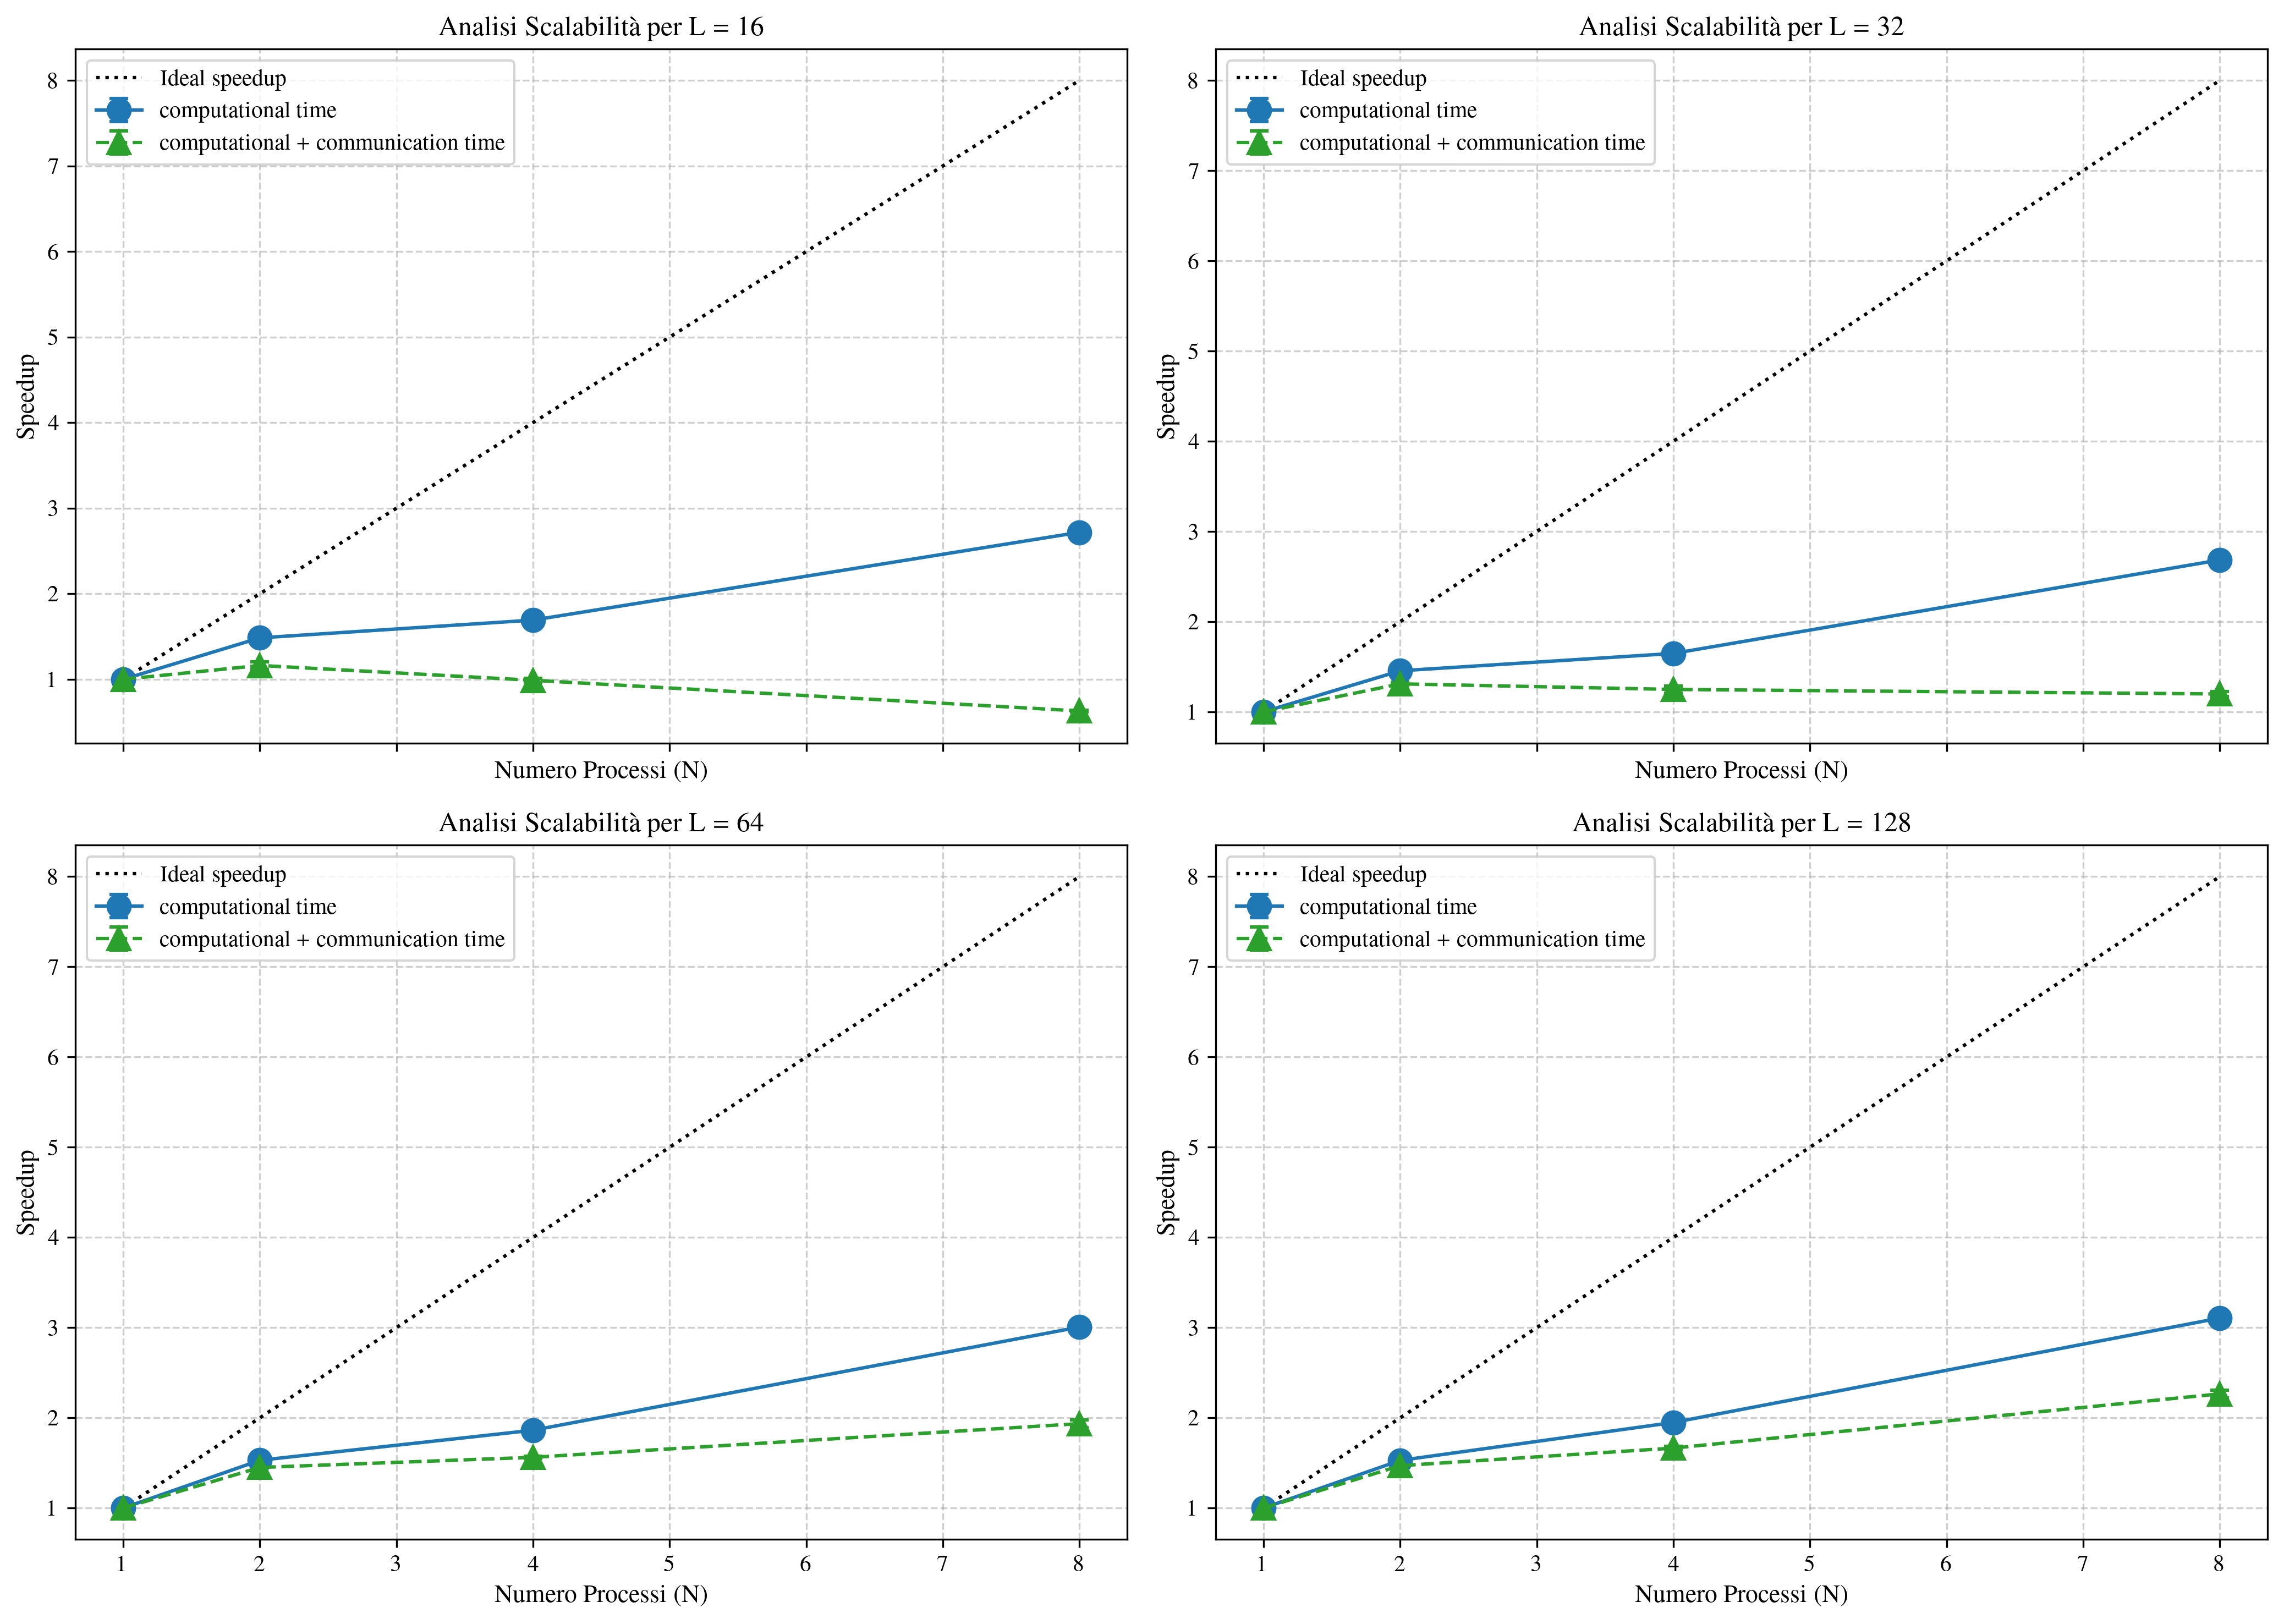

In [ ]:
data_path = "./execution_times/"

# Lista dei core testati
core_counts = [1, 2, 4, 8]
df_dict = {}

# 1. Caricamento robusto
for n in core_counts:
    filename = os.path.join(data_path, f"tempi_speedup_{n}.csv")
    if os.path.exists(filename):
        df = pd.read_csv(filename)
        
        # Creiamo subito la colonna algo_time (calcolo + comunicazione)
        if 'comm_time' in df.columns:
            df['algo_time'] = df['comp_time'] + df['comm_time']
        else:
            df['algo_time'] = df['comp_time'] # Fallback per file vecchi
            
        df_dict[n] = df
        print(f"Caricato correttamente: {filename}")
    else:
        print(f"ERRORE: File non trovato al percorso: {filename}")

# Recupero dati di riferimento (N=1)
if 1 not in df_dict:
    raise ValueError("Nessun file CSV per N=1 caricato! Controlla il percorso.")

df_base = df_dict[1]
L_values = sorted(df_base['L'].unique())

# 2. Setup Subplots
# Creiamo una griglia 2x2 per 4 taglie di L
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten() # Rendiamo l'array di assi monodimensionale per iterare facilmente

# 3. Ciclo di Plotting su Subplots
for i, L in enumerate(L_values):
    if i >= len(axes):
        break # Evita errori se abbiamo più di 4 L nel file
    
    ax = axes[i]
    
    # Estraiamo gli ARRAY grezzi (tutte le iterazioni) per N=1
    t1_comp_array = df_base[df_base['L'] == L]['comp_time'].values
    t1_algo_array = df_base[df_base['L'] == L]['algo_time'].values
    
    speedup_c = []
    speedup_c_err = []
    
    speedup_algo = []
    speedup_algo_err = []
    
    cores_found = []
    
    for n in core_counts:
        if n in df_dict and L in df_dict[n]['L'].values:
            df_n = df_dict[n]
            
            # Estraiamo gli ARRAY grezzi per N processori
            tn_comp_array = df_n[df_n['L'] == L]['comp_time'].values
            tn_algo_array = df_n[df_n['L'] == L]['algo_time'].values
            
            # Allineamento lunghezze (per sicurezza, nel caso in cui una run si sia interrotta a metà)
            min_len = min(len(t1_comp_array), len(tn_comp_array))
            t1_c_cut = t1_comp_array[:min_len]
            tn_c_cut = tn_comp_array[:min_len]
            
            t1_a_cut = t1_algo_array[:min_len]
            tn_a_cut = tn_algo_array[:min_len]
            
            # 1) Calcolo diretto degli ARRAY di speedup (divisione elemento per elemento)
            s_comp_array = t1_c_cut / tn_c_cut
            s_algo_array = t1_a_cut / tn_a_cut
            
            # 2) Calcolo media e deviazione standard empirica (ddof=1) direttamente sugli speedup
            speedup_c.append(np.mean(s_comp_array))
            speedup_c_err.append(np.std(s_comp_array, ddof=1) if min_len > 1 else 0.0)
            
            speedup_algo.append(np.mean(s_algo_array))
            speedup_algo_err.append(np.std(s_algo_array, ddof=1) if min_len > 1 else 0.0)
            
            cores_found.append(n)
    
    # Plot nel subplot specifico usando plt.errorbar
    ax.errorbar(cores_found, speedup_c, yerr=speedup_c_err, marker='o', markersize=10, color='tab:blue', 
                linestyle='-', label='computational time', capsize=4, capthick=1.5)
    
    ax.errorbar(cores_found, speedup_algo, yerr=speedup_algo_err, marker='^', markersize=10, color='tab:green', 
                linestyle='--', label='computational + communication time', capsize=4, capthick=1.5)
    
    ax.plot(core_counts, core_counts, 'k:', label='Ideal speedup', linewidth=1.5)
    
    ax.set_title(f'Analisi Scalabilità per L = {L}')
    ax.set_ylabel('Speedup')
    ax.set_xlabel('Numero Processi (N)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Assicuriamoci che la cartella assets esista, se no la creiamo
os.makedirs("./assets", exist_ok=True)
plt.savefig("./assets/scaling_speedup.png")
plt.show()